# Reto 1 – Análisis de temperatura y humedad

**Objetivo:** Analizar la relación entre la temperatura, la humedad y la biomasa.

Carga el conjunto de datos y explora las variables relevantes.

In [1]:
import pandas as pd

df = pd.read_csv("../data/resultados_experimentos.csv")
df.head()


,sitio,temperatura,humedad,luz,biomasa
0,Bosque Alto de Nocaima,23.8,82.2,1030,250.8
1,Humedal Facatativá,18.0,89.7,395,225.8
2,Río San Francisco,17.2,85.4,647,237.5
3,Ladera de La Vega,21.7,81.4,769,252.4
4,Zona Húmeda El Vergel,24.1,85.3,1333,302.7


## Exploración inicial
Describe las columnas y analiza los tipos de datos.

In [2]:
# Revisar información general del DataFrame
print("Columnas del DataFrame:")
print(df.columns)

print("\nInformación general:")
df.info()

print("\nEstadísticas descriptivas:")
display(df.describe())


Columnas del DataFrame:
Index(['sitio', 'temperatura', 'humedad', 'luz', 'biomasa'], dtype='object')

Información general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   sitio        20 non-null     object 
 1   temperatura  20 non-null     float64
 2   humedad      20 non-null     float64
 3   luz          20 non-null     int64  
 4   biomasa      20 non-null     float64
dtypes: float64(3), int64(1), object(1)
memory usage: 932.0+ bytes

Estadísticas descriptivas:


,temperatura,humedad,luz,biomasa
count,20.000000,20.000000,20.000000,20.000000
mean,20.695000,78.090000,901.000000,196.415000
std,3.259234,8.047615,307.177816,84.389369
min,14.800000,63.200000,395.000000,54.800000
25%,18.600000,72.350000,670.250000,105.650000
50%,20.400000,76.250000,893.500000,227.050000
75%,23.650000,82.975000,1048.000000,253.975000
max,27.700000,93.000000,1482.000000,315.600000


In [3]:
# Limpiar nombres de columnas
df.columns = df.columns.str.strip().str.lower()

df.head()

,sitio,temperatura,humedad,luz,biomasa
0,Bosque Alto de Nocaima,23.8,82.2,1030,250.8
1,Humedal Facatativá,18.0,89.7,395,225.8
2,Río San Francisco,17.2,85.4,647,237.5
3,Ladera de La Vega,21.7,81.4,769,252.4
4,Zona Húmeda El Vergel,24.1,85.3,1333,302.7


## Desarrollo del reto
Aplica funciones y análisis según el objetivo. Usa `def` para definir tus funciones.

In [4]:
def resumen_termico(df):
    """
    Calcula el promedio, máximo y mínimo de temperatura y humedad.
    """
    resumen = df[["temperatura", "humedad"]].agg(["mean", "max", "min"]).T
    
    resumen = resumen.rename(columns={
        "mean": "promedio",
        "max": "maximo",
        "min": "minimo"
    })
    
    return resumen


resumen = resumen_termico(df)
resumen

,promedio,maximo,minimo
temperatura,20.695,27.7,14.8
humedad,78.090,93.0,63.2


In [5]:
def clasificar_clima(temp, hum):
    """
    Clasifica el clima según la temperatura y la humedad.
    """
    if hum >= 60 and temp >= 20:
        return "húmedo templado"
    elif hum < 60 and temp >= 20:
        return "seco templado"
    elif hum >= 60 and temp < 20:
        return "húmedo frío"
    else:
        return "seco frío"

In [6]:
df["categoria_clima"] = df.apply(
    lambda fila: clasificar_clima(fila["temperatura"], fila["humedad"]),
    axis=1
)

df.head()

,sitio,temperatura,humedad,luz,biomasa,categoria_clima
0,Bosque Alto de Nocaima,23.8,82.2,1030,250.8,húmedo templado
1,Humedal Facatativá,18.0,89.7,395,225.8,húmedo frío
2,Río San Francisco,17.2,85.4,647,237.5,húmedo frío
3,Ladera de La Vega,21.7,81.4,769,252.4,húmedo templado
4,Zona Húmeda El Vergel,24.1,85.3,1333,302.7,húmedo templado


In [7]:
tabla_clima = df.groupby("categoria_clima").size().reset_index(name="numero_sitios")

tabla_clima

,categoria_clima,numero_sitios
0,húmedo frío,9
1,húmedo templado,11


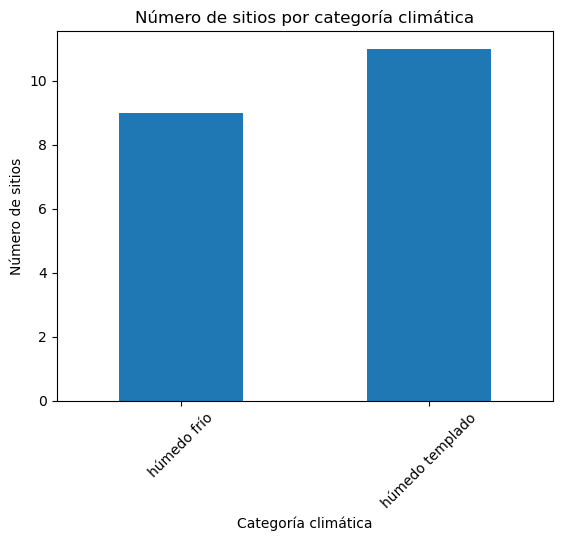

In [8]:
import matplotlib.pyplot as plt

tabla_clima.plot(
    x="categoria_clima",
    y="numero_sitios",
    kind="bar",
    legend=False
)

plt.title("Número de sitios por categoría climática")
plt.xlabel("Categoría climática")
plt.ylabel("Número de sitios")
plt.xticks(rotation=45)
plt.show()

In [9]:
df.to_csv("../data/reto1_resultado.csv", index=False)

print("Archivo reto1_resultado.csv generado correctamente.")

Archivo reto1_resultado.csv generado correctamente.


## Interpretación de resultados
Escribe tus observaciones y conclusiones sobre los patrones encontrados.

## Conclusión

En este reto se analizaron las variables de temperatura y humedad para identificar patrones climáticos relacionados con la biomasa.

Primero se cargó el conjunto de datos y se exploraron sus columnas principales. Luego se creó la función `resumen_termico(df)`, la cual permitió calcular el promedio, máximo y mínimo de temperatura y humedad.

Después se diseñó la función `clasificar_clima(temp, hum)` para clasificar cada sitio en una categoría climática según sus valores de temperatura y humedad. Esta función se aplicó a todo el DataFrame usando `apply`.

Finalmente, se generó una tabla resumen con el número de sitios por categoría climática y se exportó el archivo `reto1_resultado.csv`, que será utilizado en la integración final del grupo.